# K-Medoids: Theory and Function Overview

K-Medoids is a clustering algorithm designed to partition a dataset into **k clusters**, where each cluster is represented by one of its **actual data points**, called a **medoid**. Unlike K-Means, which uses the mean of points to define cluster centers, K-Medoids chooses medoids to **minimize the total dissimilarity within clusters**, making it more robust to outliers and noise.

The general steps of the K-Medoids algorithm are:

1. **Initialization:** Select k initial medoids randomly from the dataset.  
2. **Assignment:** Assign each data point to the **closest medoid**, forming clusters.  
3. **Update:** For each cluster, select the point (candidate medoid) that **minimizes the total distance to all other points in the cluster**.  
4. **Repeat:** Iterate the assignment and update steps until medoids no longer change, or the total cost converges.

The functions implemented in this notebook correspond directly to these steps:

---


| `compute` | Evaluates the objective function (total cost) for a medoid and its cluster. |

Together, these functions capture the **core operations of K-Medoids**, separating the algorithm into **assignment, cluster formation, and cost evaluation**, which can then be iterated until convergence.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import nbformat
import pandas as pd
from plots import *

random_seed =1



##### `assign_medoids`

This function implements the **assignment step** of the K-Medoids clustering algorithm. Given a set of medoids, each data point in the dataset is assigned to the cluster represented by its **nearest medoid**.

Formally, for each data point $x_i$, the cluster assignment is determined by selecting the medoid that minimizes the distance to that point:

$$
C(i) = \arg\min_j d(x_i, m_j)
$$

where:

- $x_i$ is a data point in the dataset  
- $m_j$ is the $j^{th}$ medoid  
- $d(x_i, m_j)$ represents the distance between the point and the medoid  
- $C(i)$ denotes the cluster assignment of point $x_i$

In this implementation, the **Euclidean distance** is used as the distance metric. The function computes the distance from each data point to all medoids and assigns the point to the medoid with the **smallest distance**.

The output of this function is a mapping that records **which medoid each point belongs to**, effectively partitioning the dataset into clusters. These assignments are then used in later steps of the algorithm to:

- construct the cluster sets  
- compute cluster costs  
- update the medoids to improve the clustering

In [2]:
def assign_medoids(data,medoids):
    x_medoid_assignment = []
    # assign the point 
    for point in data:
        distances = np.linalg.norm(point - medoids, axis=1) # compute distances
        closest_medoid = np.argmin(distances) #min distances 
        x_medoid_assignment.append(closest_medoid) # store assignment 
    return x_medoid_assignment

##### `get_points`

This function constructs the **set of data points belonging to a specific cluster**. In the K-Medoids algorithm, once each point has been assigned to its closest medoid, the dataset is partitioned into $K$ clusters. Each cluster contains the points whose nearest representative is the corresponding medoid.

Formally, after the assignment step we obtain a mapping

$$
C(i) = k
$$

which indicates that data point $x_i$ belongs to cluster $k$.

Using this mapping, the cluster associated with medoid $m_k$ can be written as

$$
C_k = \{x_i \mid C(i) = k\}
$$

where:

- $C_k$ is the set of all points assigned to cluster $k$
- $x_i$ is a data point in the dataset
- $C(i)$ represents the cluster assignment for point $x_i$

The purpose of this function is to **retrieve all points belonging to cluster $k$** based on the current assignment mapping. These cluster sets are essential for the next stage of the algorithm, where the cost of candidate medoids is evaluated and the optimal medoid is selected by minimizing the total distance within the cluster.

In [3]:


def get_points(data,x_medoid_assignment,k):
    points = []
    for i in range(len(data)):
        # position in medoids  :  3 
        if x_medoid_assignment[i] == k:
            points.append(data[i])
    return np.array(points) 



##### `compute`

This function evaluates the **cost of a candidate medoid** relative to the points assigned to its cluster. In the K-Medoids algorithm, clustering quality is measured by the **total dissimilarity between cluster points and their medoid**.

For a given cluster $C_k$ and medoid $m_k$, the cost is defined as the sum of distances between the medoid and all points in the cluster:

$$
C(m_k) = \sum_{x_i \in C_k} d(x_i, m_k)
$$

where:

- $C_k$ is the set of data points assigned to cluster $k$
- $m_k$ is the medoid representing the cluster
- $d(x_i, m_k)$ is the distance between point $x_i$ and the medoid

In this implementation, the distance metric used is the **Euclidean distance**. The function computes the distance between each point in the cluster and the candidate medoid, then sums these distances to obtain the **total cluster cost**.

This cost function is fundamental to the K-Medoids algorithm because the objective of the algorithm is to **minimize the total clustering cost across all clusters**:

$$
\text{Total Cost} =
\sum_{k=1}^{K} \sum_{x_i \in C_k} d(x_i, m_k)
$$

By evaluating this cost for different candidate medoids, the algorithm can determine which data point best represents the cluster and update the medoid accordingly.

In [4]:
def compute(points, medoid):
     #compute distance of all points 
     distances = np.linalg.norm(points - medoid, axis= 1 ) 
     # sum distances to get cost for m 
     cost = np.sum(distances)
     return cost 

##### `compute_cost`

This function implements the **medoid update step** of the K-Medoids clustering algorithm. After points have been assigned to their nearest medoids, the algorithm attempts to improve the clustering by selecting a better representative point (medoid) for each cluster.

For a given cluster, the goal is to find the data point that **minimizes the total distance to all other points in the cluster**. This corresponds to minimizing the cluster cost function:

$$
C(m_k) = \sum_{x_i \in C_k} d(x_i, m_k)
$$

where:

- $C_k$ is the set of data points assigned to cluster $k$
- $m_k$ is the current medoid of cluster $k$
- $d(x_i, m_k)$ is the distance between point $x_i$ and the medoid

The function proceeds as follows:

1. **Retrieve cluster points**

   For each medoid $m_k$, the algorithm retrieves the set of points assigned to that medoid:

   $$
   C_k = \{x_i \mid C(i) = k\}
   $$

   where $C(i)$ represents the cluster assignment of point $x_i$.

2. **Evaluate candidate medoids**

   Each point in the cluster is considered as a **potential new medoid**. For a candidate point $o$, the algorithm computes the cost:

   $$
   C(o) = \sum_{x_i \in C_k} d(x_i, o)
   $$

   This evaluates how well that point represents the cluster.

3. **Select the optimal medoid**

   The candidate with the **minimum total cost** is selected:

   $$
   m_k = \arg\min_{o \in C_k} C(o)
   $$

   This ensures the

In [5]:

     

def compute_cost(medoids, data,x_medoid_assignment):
    cost_medoids = []
    for k in range(len(medoids)):
        # get x assigned to medoids 
        points= get_points(data,x_medoid_assignment,k)
        cost = compute(points, medoids[k])
        # check C(m) vs C(o)
        all_possible_costs = []
        for i in range(len(points)):
             #recompute the distance here 
             new_medoid = points[i]
             # compute new cost 
             O_cost = compute(points, new_medoid)
             # add to list of all cost for the medroid 
             all_possible_costs.append(O_cost)

        all_possible_costs= np.array(all_possible_costs)

        # find min cost and reassign medoids 
        min_idx = np.argmin(all_possible_costs)
        medoids[k] = points[min_idx]
        cost = all_possible_costs[min_idx]
        cost_medoids.append(cost)
        
        # reassign data points based on new medoids 
        x_medoid_assignment = assign_medoids(data,medoids)
             

    return medoids,x_medoid_assignment, np.array(cost_medoids)




#### `k_medoids`

This function implements the **full K-Medoids clustering algorithm**, which partitions a dataset into $K$ clusters using **representative data points (medoids)** instead of means. Unlike K-Means, medoids are always **actual observations from the dataset**, which makes the algorithm more robust to outliers.

The objective of K-Medoids is to minimize the **total clustering cost**, defined as the sum of distances between each data point and the medoid representing its cluster.

$$
\text{Total Cost} =
\sum_{k=1}^{K} \sum_{x_i \in C_k} d(x_i, m_k)
$$

where:

- $K$ is the number of clusters  
- $C_k$ is the set of points assigned to cluster $k$  
- $m_k$ is the medoid of cluster $k$  
- $d(x_i, m_k)$ is the distance between point $x_i$ and medoid $m_k$

---

##### Algorithm Procedure

The implementation follows an **iterative optimization process** consisting of initialization, assignment, and medoid update steps.

**1. Initialization**

The algorithm begins by randomly selecting $K$ data points from the dataset to serve as the **initial medoids**.

$$
M = \{m_1, m_2, \dots, m_K\}
$$

These points act as the initial cluster representatives.

---

**2. Cluster Assignment**

Each data point is assigned to the cluster whose medoid is **closest in terms of distance**:

$$
C(i) = \arg\min_j d(x_i, m_j)
$$

This partitions the dataset into $K$ clusters.

---

**3. Medoid Update**

For each cluster $C_k$, the algorithm searches for the point that minimizes the **total distance to all other points in the cluster**:

$$
m_k = \arg\min_{o \in C_k}
\sum_{x_i \in C_k} d(x_i, o)
$$

If a better medoid is found, the cluster representative is updated.

---

**4. Iterative Optimization**

After updating the medoids, the algorithm recomputes cluster assignments and evaluates the **new total cost**. This process repeats until the clustering cost **no longer decreases**, indicating convergence.

$$
\text{Stop when } \text{Cost}_{new} \geq \text{Cost}_{previous}
$$

---

##### Visualization and Iteration Tracking

During each iteration, the algorithm stores:

- the current medoid locations  
- the cluster assignments for each data point  

This information is recorded in a history structure, allowing the clustering process to be **visualized across iterations**. The stored data is later transformed into a dataset suitable for plotting and animated visualization of how clusters evolve during optimization.

---

##### Output

The function returns:

- the **final clustering cost**
- the **final medoid locations**
- the **cluster assignment for each data point**

These outputs represent the final clustering configuration produced by the K-Medoids algorithm.

In [6]:
def k_medoids(data, k ):
    # set seed 
    random_seed= 1
    np.random.seed(random_seed) 

    # pick 3 unique indices from the data set 
    random_indices = np.random.choice(data.shape[0], k , replace = False)

    # get the values from the indices data[i]
    medoids = data[random_indices]
    x_medoid_assignment= assign_medoids(data,medoids)
    
    m_cost_sum = np.inf
    iteration = 0
    history = []  # will store medoid + cluster info per iteration 

    while True:
    # get updated variables 
        medoids,x_medoid_assignment,m_cost = compute_cost(medoids, data,x_medoid_assignment)
        new_cost_sum = np.sum(m_cost)

        # plot_iteration(data, medoids, x_medoid_assignment, iteration)
        # Store for Plotly
        iteration_data = {
            "iteration": iteration,
            "medoids": medoids.copy(),
            "assignments": x_medoid_assignment.copy()
        }
        history.append(iteration_data)

        iteration += 1


        if new_cost_sum >= m_cost_sum:
            break
        m_cost_sum = new_cost_sum

    frames = []
    for h in history:
        iteration = h["iteration"]
        medoids = h["medoids"]
        assignments = h["assignments"]
        
        df_iter = pd.DataFrame(data, columns=["x", "y"])
        df_iter["cluster"] = assignments
        df_iter["iteration"] = iteration
        frames.append(df_iter)

    df_plotly = pd.concat(frames, ignore_index=True)
    plot_kmedoids_animation(history,df_plotly)


            
    return new_cost_sum,medoids,x_medoid_assignment

    

#### Synthetic Dataset Generation

Before applying the K-Medoids algorithm, we generate a **synthetic dataset** consisting of multiple clusters in two-dimensional space. Synthetic data allows us to evaluate clustering behavior in a controlled environment where the underlying structure of the data is known.

---

##### Cluster Structure

The dataset is constructed by generating $K$ cluster centers randomly within a bounded region of the 2D plane:

$$
c_k \sim \text{Uniform}(-10, 10)
$$

where:

- $c_k$ represents the center of cluster $k$
- $K$ is the number of clusters

Each cluster center serves as the **true underlying location** around which data points will be distributed.

---

##### Data Generation

For each cluster center $c_k$, data points are sampled using a **Gaussian distribution**:

$$
x_i = c_k + \sigma \cdot \epsilon
$$

where:

- $x_i$ is a generated data point
- $c_k$ is the cluster center
- $\sigma$ controls the spread of the cluster
- $\epsilon \sim \mathcal{N}(0, I)$ is a random vector drawn from a standard normal distribution

The parameter $\sigma$ determines how tightly the points are distributed around the center. Larger values produce **more dispersed clusters**, while smaller values produce **tighter clusters**.

---

##### Dataset Composition

The final dataset is constructed by stacking the generated clusters together to form a single matrix:

$$
X = \{x_1, x_2, \dots, x_n\}
$$

where $n = K \times$ (points per cluster).

This dataset serves as the input to the **K-Medoids clustering algorithm**, which attempts to recover the underlying cluster structure by identifying representative medoids.

---

##### Visualization

To better understand the dataset, the points are plotted in two-dimensional space. Visualizing the data provides an intuitive view of the cluster structure before applying the clustering algorithm.

Text(0, 0.5, 'Y')

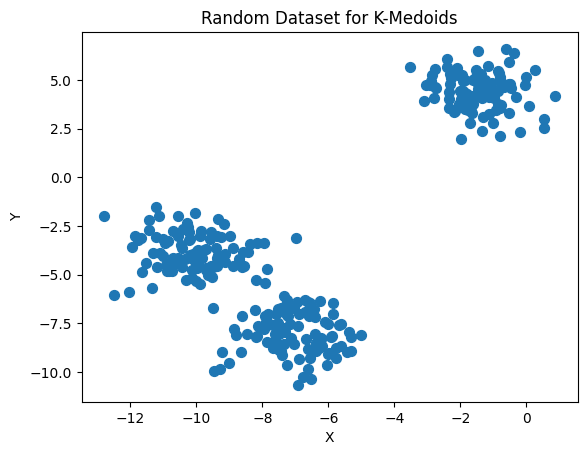

In [7]:

# Parameters
n_clusters = 3
points_per_cluster = 100
cluster_std = 1 # how spread out the clusters are
dim = 2  # 2D data

# Generate random cluster centers
np.random.seed(random_seed)  # for reproducibility
centers = np.random.uniform(-10, 10, (n_clusters, dim))

# Generate points around each center
data = []
for center in centers:
    cluster_points = center + cluster_std * np.random.randn(points_per_cluster, dim)
    data.append(cluster_points)

data = np.vstack(data)  # combine all points

# Plot the dataset
plt.scatter(data[:, 0], data[:, 1], s=50)
plt.title("Random Dataset for K-Medoids")
plt.xlabel("X")
plt.ylabel("Y")
# plt.show()

In [8]:
print(k_medoids(data=data, k = n_clusters))


(np.float64(368.73040687704577), array([[ -1.37889483,   4.33337717],
       [ -7.31655639,  -7.77051293],
       [-10.10770399,  -3.9447996 ]]), [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64